### Verificación de las cuestiones

In [57]:
# Revisando que todo esté en orden
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
pd.set_option('display.max_columns',34)

print(f"pandas ready     {pd.__version__}")
print(f"matplotlib ready {plt.matplotlib.__version__}")
print(f"seaborn ready    {sns.__version__}")
print(f"scikit-learn ready {sklearn.__version__}")
print("\nEso es todo")

pandas ready     3.0.1
matplotlib ready 3.10.8
seaborn ready    0.13.2
scikit-learn ready 1.8.0

Eso es todo


### Cargar dataset 

In [58]:
# use a subset of columns, for simplicity and speed
columns = ['question_id', 'title', 'body', 'tags', 'tag_count',
       'programming_language', 'categories', 'creation_date', 'creation_year',
       'creation_month', 'creation_weekday', 'last_activity_date',
       'view_count', 'score', 'answer_count', 'comment_count',
       'favorite_count', 'is_answered', 'has_accepted_answer',
       'accepted_answer_score', 'has_code', 'code_block_count',
       'title_word_count', 'title_char_count', 'body_word_count',
       'body_char_count', 'difficulty_score', 'quality_score',
       'owner_reputation', 'owner_badge_count', 'first_response_time_seconds',
       'first_response_time_hours', 'top_answer_score',
       'top_answer_body_length']

# Carga del dataset de kaggle
df = pd.read_csv("../dataset/stackoverflow_combined.csv", index_col="question_id", parse_dates=["creation_date"], usecols=columns)

print(f"Dataset listo")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Dataset listo
Filas: 95,636
Columnas: 33


### Revisión de filas

In [59]:
# Revisar las 10 primeras filas
df.head(10)

,title,body,tags,tag_count,programming_language,categories,creation_date,creation_year,creation_month,creation_weekday,last_activity_date,view_count,score,answer_count,comment_count,favorite_count,is_answered,has_accepted_answer,accepted_answer_score,has_code,code_block_count,title_word_count,title_char_count,body_word_count,body_char_count,difficulty_score,quality_score,owner_reputation,owner_badge_count,first_response_time_seconds,first_response_time_hours,top_answer_score,top_answer_body_length
question_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
79810291,AttributeError: 'NoneType' object has no attri...,I am trying to develop a tool that agent (Code...,"python, artificial-intelligence, huggingface, ...",4,python,"bug, api, backend",2025-11-05 15:49:00,2025,11,2,2025-11-05 15:57:09,18,-1,0,0,0,False,False,0,True,2,12,81,36,190,0.200,0.70,345,0,NaN,NaN,0,0
79810195,"contextlib tries to change a ""frozen"" exception",I got a strange error in my pytest after some ...,"python, minio",2,python,"bug, testing",2025-11-05 14:23:06,2025,11,2,2025-11-05 14:25:06,29,0,0,0,0,False,False,0,True,3,7,47,113,599,0.200,0.70,529,0,NaN,NaN,0,0
79810063,Tkinter window shrinks after embedding Matplot...,I'm building a multi-frame Tkinter app for a s...,"python, matplotlib, tkinter",3,python,"api, backend",2025-11-05 12:42:01,2025,11,2,2025-11-05 12:42:01,27,2,0,0,0,False,False,0,True,11,12,77,143,812,0.201,0.70,21,0,NaN,NaN,0,0
79810057,"CatalystAppError: {'code': 'FATAL ERROR', 'mes...",I’m working on a chatbot project using the Zoh...,"python, zoho, zohocatalyst",3,python,bug,2025-11-05 12:36:07,2025,11,2,2025-11-05 12:45:43,48,0,0,0,0,False,False,0,True,3,13,113,124,905,0.202,0.68,9,0,NaN,NaN,0,0
79810049,Sympy : Problem with simplifying a Sympy vecto...,I am creating my own coordinate system using t...,"python, sympy",2,python,bug,2025-11-05 12:28:43,2025,11,2,2025-11-05 14:38:19,44,1,0,0,0,False,False,0,True,7,11,80,109,710,0.199,0.70,1620,0,NaN,NaN,0,0
79809980,Turn off Gemini's reasoning in DSPy,"In my DSPy project, I am using Gemini 2.5 Flas...","python, google-gemini, reasoning, dspy",4,python,NaN,2025-11-05 11:37:00,2025,11,2,2025-11-05 12:14:05,39,2,1,0,0,True,False,0,True,1,6,35,45,239,0.201,0.90,324,0,1852.0,0.514444,2,78
79809939,The Pyrogram client does not recognize the id ...,Below are two scripts. The first one creates a...,"python, telegram, aiogram, pyrogram",4,python,bug,2025-11-05 10:56:42,2025,11,2,2025-11-05 15:14:33,52,1,1,0,0,False,False,0,True,3,13,71,138,768,0.202,0.90,59,0,14587.0,4.051944,0,450
79809924,Python SSH automation. Child process communica...,I am trying to automate SSH authentication on ...,"python, ssh, automation, tty",4,python,"bug, security, backend",2025-11-05 10:36:06,2025,11,2,2025-11-05 11:11:42,57,1,0,0,0,False,False,0,True,1,9,71,151,925,0.202,0.70,21,0,NaN,NaN,0,0
79809886,A wrapper route to simulate a FastAPI request,My goal is to have a special route which recei...,"python, fastapi, middleware, asgi",4,python,"api, backend",2025-11-05 10:04:13,2025,11,2,2025-11-05 13:50:53,51,0,1,0,0,False,False,0,True,2,8,45,102,567,0.202,0.90,197,0,13600.0,3.777778,0,21


### Revision de columnas

In [60]:
df.columns

Index(['title', 'body', 'tags', 'tag_count', 'programming_language',
       'categories', 'creation_date', 'creation_year', 'creation_month',
       'creation_weekday', 'last_activity_date', 'view_count', 'score',
       'answer_count', 'comment_count', 'favorite_count', 'is_answered',
       'has_accepted_answer', 'accepted_answer_score', 'has_code',
       'code_block_count', 'title_word_count', 'title_char_count',
       'body_word_count', 'body_char_count', 'difficulty_score',
       'quality_score', 'owner_reputation', 'owner_badge_count',
       'first_response_time_seconds', 'first_response_time_hours',
       'top_answer_score', 'top_answer_body_length'],
      dtype='str')

### Estructura del dataset

In [61]:
#Tipos de datos y valores nulos
df.info()

<class 'pandas.DataFrame'>
Index: 95636 entries, 79810291 to 78654946
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   title                        95636 non-null  str           
 1   body                         95614 non-null  str           
 2   tags                         95636 non-null  str           
 3   tag_count                    95636 non-null  int64         
 4   programming_language         95636 non-null  str           
 5   categories                   71744 non-null  str           
 6   creation_date                95636 non-null  datetime64[us]
 7   creation_year                95636 non-null  int64         
 8   creation_month               95636 non-null  int64         
 9   creation_weekday             95636 non-null  int64         
 10  last_activity_date           95636 non-null  str           
 11  view_count                   95636 non-null  in

### Rows with nulls

In [62]:
#Filas con los valores nulos
df[df.isna().any(axis=1)]

,title,body,tags,tag_count,programming_language,categories,creation_date,creation_year,creation_month,creation_weekday,last_activity_date,view_count,score,answer_count,comment_count,favorite_count,is_answered,has_accepted_answer,accepted_answer_score,has_code,code_block_count,title_word_count,title_char_count,body_word_count,body_char_count,difficulty_score,quality_score,owner_reputation,owner_badge_count,first_response_time_seconds,first_response_time_hours,top_answer_score,top_answer_body_length
question_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
79810291,AttributeError: 'NoneType' object has no attri...,I am trying to develop a tool that agent (Code...,"python, artificial-intelligence, huggingface, ...",4,python,"bug, api, backend",2025-11-05 15:49:00,2025,11,2,2025-11-05 15:57:09,18,-1,0,0,0,False,False,0,True,2,12,81,36,190,0.200,0.70,345,0,NaN,NaN,0,0
79810195,"contextlib tries to change a ""frozen"" exception",I got a strange error in my pytest after some ...,"python, minio",2,python,"bug, testing",2025-11-05 14:23:06,2025,11,2,2025-11-05 14:25:06,29,0,0,0,0,False,False,0,True,3,7,47,113,599,0.200,0.70,529,0,NaN,NaN,0,0
79810063,Tkinter window shrinks after embedding Matplot...,I'm building a multi-frame Tkinter app for a s...,"python, matplotlib, tkinter",3,python,"api, backend",2025-11-05 12:42:01,2025,11,2,2025-11-05 12:42:01,27,2,0,0,0,False,False,0,True,11,12,77,143,812,0.201,0.70,21,0,NaN,NaN,0,0
79810057,"CatalystAppError: {'code': 'FATAL ERROR', 'mes...",I’m working on a chatbot project using the Zoh...,"python, zoho, zohocatalyst",3,python,bug,2025-11-05 12:36:07,2025,11,2,2025-11-05 12:45:43,48,0,0,0,0,False,False,0,True,3,13,113,124,905,0.202,0.68,9,0,NaN,NaN,0,0
79810049,Sympy : Problem with simplifying a Sympy vecto...,I am creating my own coordinate system using t...,"python, sympy",2,python,bug,2025-11-05 12:28:43,2025,11,2,2025-11-05 14:38:19,44,1,0,0,0,False,False,0,True,7,11,80,109,710,0.199,0.70,1620,0,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78663287,BigQuery unable to split and pivot data,I have a table with concatenated error message...,"sql, google-bigquery",2,sql,"bug, database",2024-06-24 15:10:05,2024,6,0,2024-06-24 15:37:58,35,0,0,0,0,False,False,0,False,0,7,39,83,565,0.201,0.60,1,0,NaN,NaN,0,0
78660795,Counting items by statuses and changing counte...,I am building a laravel website where I need t...,"sql, laravel",2,sql,"performance, database",2024-06-24 06:14:29,2024,6,0,2024-06-24 07:14:33,46,0,0,0,0,False,False,0,True,4,9,57,77,386,0.202,0.70,15,0,NaN,NaN,0,0
78658909,"How do I make SQLITE query with limits, random...",In SQLITE LIMIT cannot be used in queries whic...,"sql, sqlite",2,sql,"database, how-to",2024-06-23 14:11:15,2024,6,6,2024-06-25 10:19:06,82,0,0,0,0,False,False,0,True,8,13,72,162,831,0.203,0.70,51,0,NaN,NaN,0,0


In [63]:
# Revisar valores nulos por columna
nulos = df.isnull().sum()
nulos_porcentaje = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "valores_nulos": nulos,
    "porcentaje": nulos_porcentaje
})

# Solo mostrar columnas que sí tienen nulos
print(resumen_nulos[resumen_nulos["valores_nulos"] > 0])

                             valores_nulos  porcentaje
body                                    22        0.02
categories                           23892       24.98
first_response_time_seconds          29208       30.54
first_response_time_hours            29208       30.54


### Deleting rows with no body

In [64]:
# Eliminar las 22 filas sin body
df = df.dropna(subset=["body"])

print(f"Filas antes:  95,636")
print(f"Filas después: {len(df):,}")
print(f"Filas eliminadas: {95636 - len(df)}")

Filas antes:  95,636
Filas después: 95,614
Filas eliminadas: 22


### Histogram

array([[<Axes: title={'center': 'creation_date'}>]], dtype=object)

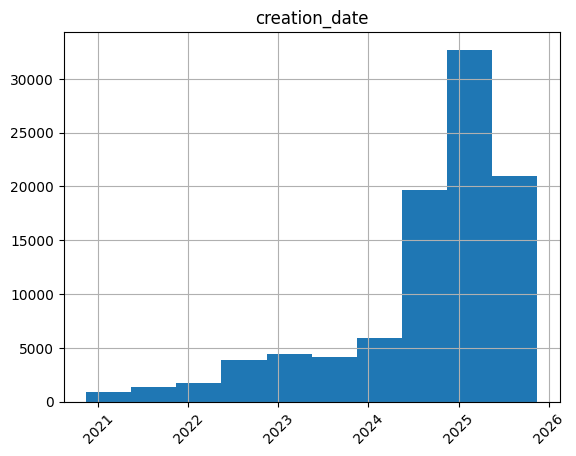

In [65]:
df.hist("creation_date", xrot=45)

### Unique values

In [66]:
counts = df["programming_language"].value_counts()

print(counts.to_string())

programming_language
javascript    7353
python        6488
java          5945
c++           5272
c#            5166
swift         5043
r             5014
c             4868
rust          4847
ruby          4840
sql           4821
php           4812
go            4811
kotlin        4543
scala         4526
matlab        4155
typescript    4072
perl          3853
html          3200
css           1781
bash           124
shell           47
powershell      22
dart             8
haskell          3


### Estadistica general

In [67]:
#Resumen estadistico
df.describe()

,tag_count,creation_date,creation_year,creation_month,creation_weekday,view_count,score,answer_count,comment_count,favorite_count,accepted_answer_score,code_block_count,title_word_count,title_char_count,body_word_count,body_char_count,difficulty_score,quality_score,owner_reputation,owner_badge_count,first_response_time_seconds,first_response_time_hours,top_answer_score,top_answer_body_length
count,95614.000000,95614,95614.000000,95614.000000,95614.000000,95614.000000,95614.000000,95614.000000,95614.0,95614.0,95614.000000,95614.000000,95614.000000,95614.000000,95614.000000,95614.000000,95614.000000,95614.000000,9.561400e+04,95614.0,6.641500e+04,66415.000000,95614.000000,95614.000000
mean,3.283138,2024-09-03 18:51:57.616991,2024.175780,6.504811,2.664432,241.576004,0.711172,0.975276,0.0,0.0,0.754848,4.188979,10.408193,64.403414,116.496141,665.635419,0.205000,0.871402,2.910807e+03,0.0,4.701032e+05,130.584225,1.156138,372.930439
min,1.000000,2020-11-13 10:58:06,2020.000000,1.000000,0.000000,2.000000,-18.000000,0.000000,0.0,0.0,-6.000000,0.000000,1.000000,7.000000,1.000000,2.000000,0.001000,0.300000,0.000000e+00,0.0,0.000000e+00,0.000000,-6.000000,0.000000
25%,2.000000,2024-06-11 10:33:23,2024.000000,3.000000,1.000000,63.000000,0.000000,0.000000,0.0,0.0,0.000000,1.000000,7.000000,47.000000,62.000000,345.000000,0.201000,0.700000,1.900000e+01,0.0,2.252000e+03,0.625556,0.000000,0.000000
50%,3.000000,2024-12-20 00:08:11.500000,2024.000000,7.000000,3.000000,97.000000,0.000000,1.000000,0.0,0.0,0.000000,3.000000,10.000000,61.000000,96.000000,537.000000,0.203000,0.900000,9.300000e+01,0.0,9.904000e+03,2.751111,0.000000,193.000000
75%,4.000000,2025-04-26 17:02:27.250000,2025.000000,10.000000,4.000000,175.000000,1.000000,1.000000,0.0,0.0,1.000000,5.000000,13.000000,78.000000,146.000000,834.000000,0.209000,1.000000,8.450000e+02,0.0,6.253650e+04,17.371250,2.000000,489.000000
max,5.000000,2025-11-14 23:42:35,2025.000000,12.000000,6.000000,317919.000000,195.000000,16.000000,0.0,0.0,278.000000,84.000000,33.000000,151.000000,2733.000000,17924.000000,0.993000,1.000000,1.010847e+06,0.0,1.002907e+08,27858.523889,278.000000,21783.000000
std,1.186846,NaN,1.038247,3.428209,1.856053,1963.537012,1.987951,0.887096,0.0,0.0,2.146535,4.547430,4.166614,24.082092,84.158727,520.831580,0.026877,0.129175,1.591034e+04,0.0,2.878696e+06,799.637902,2.536195,591.062040


### Revisar los lenguajes disponibles

In [68]:
# Revisar cuales son los lenguajes que aparecen
print("Lenguajes del dataset:")
print(df["programming_language"].unique())
print(f"\nTotal: {df["programming_language"].nunique()} lenguajes")

Lenguajes del dataset:
<StringArray>
[    'python', 'javascript',       'html',       'java',         'c#',
        'php',        'c++',          'c',          'r',        'sql',
        'css',         'go', 'typescript',       'dart',      'shell',
       'bash', 'powershell',      'swift',       'ruby',     'kotlin',
      'scala',       'rust',    'haskell',     'matlab',       'perl']
Length: 25, dtype: str

Total: 25 lenguajes


### Columnas utiles 

In [69]:
df = df[[
#     'title', 'body', 'tags', 'tag_count', 
       'programming_language',
       #'categories', 
       'creation_date', 
       #'creation_year', 'creation_month', 'creation_weekday', 'last_activity_date', 
       'view_count', 'score', 'answer_count', 
       #'comment_count', 'favorite_count',
       'is_answered', 'has_accepted_answer',
       #'accepted_answer_score', 'has_code','code_block_count', 'title_word_count', 'title_char_count', 'body_word_count', 'body_char_count', 
       'difficulty_score', 'quality_score',
       #'owner_reputation', 'owner_badge_count','first_response_time_seconds', 'first_response_time_hours','top_answer_score', 'top_answer_body_length'
       ]].copy()

df

,programming_language,creation_date,view_count,score,answer_count,is_answered,has_accepted_answer,difficulty_score,quality_score
question_id,,,,,,,,,
79810291,python,2025-11-05 15:49:00,18,-1,0,False,False,0.200,0.70
79810195,python,2025-11-05 14:23:06,29,0,0,False,False,0.200,0.70
79810063,python,2025-11-05 12:42:01,27,2,0,False,False,0.201,0.70
79810057,python,2025-11-05 12:36:07,48,0,0,False,False,0.202,0.68
79810049,python,2025-11-05 12:28:43,44,1,0,False,False,0.199,0.70
...,...,...,...,...,...,...,...,...,...
78655811,php,2024-06-22 10:49:21,301,0,0,False,False,0.212,0.70
78655651,sql,2024-06-22 09:40:40,132,0,1,True,True,0.213,1.00
78655545,sql,2024-06-22 08:51:37,89,0,2,True,True,0.206,1.00


### Filas no deseadas


In [70]:
no_lenguajes = ["shell", "bash", "powershell", "html", "css"]

df = df[~df["programming_language"].isin(no_lenguajes)].copy()

In [71]:
df

,programming_language,creation_date,view_count,score,answer_count,is_answered,has_accepted_answer,difficulty_score,quality_score
question_id,,,,,,,,,
79810291,python,2025-11-05 15:49:00,18,-1,0,False,False,0.200,0.70
79810195,python,2025-11-05 14:23:06,29,0,0,False,False,0.200,0.70
79810063,python,2025-11-05 12:42:01,27,2,0,False,False,0.201,0.70
79810057,python,2025-11-05 12:36:07,48,0,0,False,False,0.202,0.68
79810049,python,2025-11-05 12:28:43,44,1,0,False,False,0.199,0.70
...,...,...,...,...,...,...,...,...,...
78655811,php,2024-06-22 10:49:21,301,0,0,False,False,0.212,0.70
78655651,sql,2024-06-22 09:40:40,132,0,1,True,True,0.213,1.00
78655545,sql,2024-06-22 08:51:37,89,0,2,True,True,0.206,1.00
